# Advanced Financial Technology — Final Coursework


## Imports and Configuration

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
from scipy.stats import norm
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from arch import arch_model
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

DATA_PATH = '2526ADFTcourseworkData.csv'
FF3_PATH  = 'ff3 factor.csv'

# Constants
RF_ANNUAL = 0.05        # risk-free rate (annual)
A_COEFF   = 5           # risk-aversion coefficient
STOCKS    = ['AAPL', 'DIS', 'FMC', 'KO', 'ORA']
ASSIGNED  = 'KO'        # Coca-Cola
NAMES     = {'AAPL':'Apple','DIS':'Walt Disney','FMC':'FMC Corp','KO':'Coca-Cola','ORA':'Ormat Tech'}
N_SIM     = 10_000      # Monte Carlo simulations
plt.rcParams['figure.dpi'] = 120

---
## Task 1: Data Cleaning

In [3]:
# Load data
prices_raw = pd.read_csv(DATA_PATH, index_col='Date', parse_dates=True)
print(f"Raw dataset: {prices_raw.shape[0]} rows × {prices_raw.shape[1]} columns")
print(f"Date range : {prices_raw.index[0].date()} → {prices_raw.index[-1].date()}")
print("\nMissing values per stock:")
print(prices_raw.isnull().sum().to_string())
print(f"\nTotal missing cells: {prices_raw.isnull().sum().sum()}")


Raw dataset: 2518 rows × 5 columns
Date range : 2013-01-02 → 2022-12-30

Missing values per stock:
AAPL    31
DIS     32
FMC     41
KO      47
ORA     37

Total missing cells: 188


In [4]:
# Treatment: forward-fill
prices = prices_raw.ffill().dropna()

print("After forward-fill + dropna:")
print(f"  Missing values: {prices.isnull().sum().sum()}")
print(f"  Shape: {prices.shape}")

# Daily log returns
log_returns = np.log(prices / prices.shift(1)).dropna()
print(f"\nLog returns computed: {log_returns.shape[0]} observations")
print("\nDescriptive statistics:")
print(log_returns.describe().round(6).to_string())


After forward-fill + dropna:
  Missing values: 0
  Shape: (2518, 5)

Log returns computed: 2517 observations

Descriptive statistics:
              AAPL          DIS          FMC           KO          ORA
count  2517.000000  2517.000000  2517.000000  2517.000000  2517.000000
mean      0.000811     0.000249     0.000408     0.000334     0.000609
std       0.018291     0.016691     0.018956     0.011403     0.019894
min      -0.137708    -0.141139    -0.215084    -0.101728    -0.140315
25%      -0.007410    -0.006680    -0.008533    -0.004458    -0.008409
50%       0.000524     0.000198     0.000000     0.000455     0.000922
75%       0.010157     0.007663     0.009490     0.005725     0.010228
max       0.113158     0.134638     0.128402     0.062783     0.150415


In [5]:
# Annualised summary
ann_ret = log_returns.mean() * 252
ann_vol = log_returns.std() * np.sqrt(252)

summary = pd.DataFrame({'Ann. Return': ann_ret, 'Ann. Volatility': ann_vol},
                       index=STOCKS)
print("Annualised statistics:")
print(summary.applymap(lambda x: f"{x*100:.2f}%"))


Annualised statistics:
     Ann. Return Ann. Volatility
AAPL      20.44%          29.04%
DIS        6.27%          26.50%
FMC       10.27%          30.09%
KO         8.41%          18.10%
ORA       15.35%          31.58%


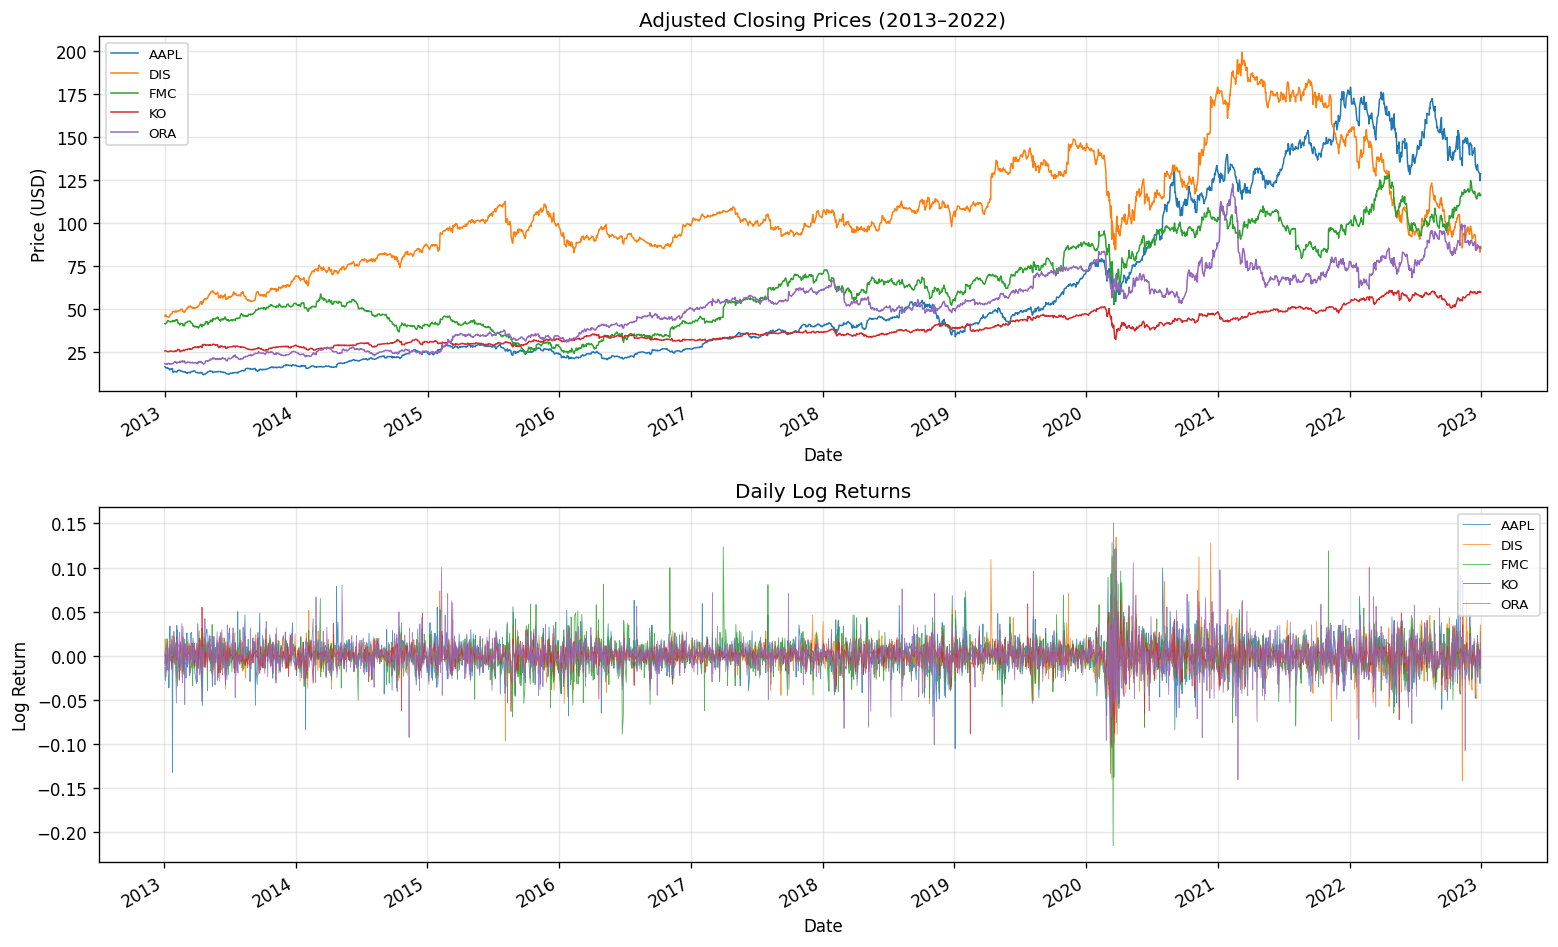

In [6]:
# Visualisation
fig, axes = plt.subplots(2, 1, figsize=(13, 8))

prices.plot(ax=axes[0], lw=0.9, title='Adjusted Closing Prices (2013–2022)')
axes[0].set_ylabel('Price (USD)'); axes[0].legend(STOCKS, loc='upper left', fontsize=8)
axes[0].grid(alpha=0.3)

log_returns.plot(ax=axes[1], lw=0.5, alpha=0.8, title='Daily Log Returns')
axes[1].set_ylabel('Log Return'); axes[1].legend(STOCKS, loc='upper right', fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fig_task1_prices_returns.png', bbox_inches='tight')
plt.show()

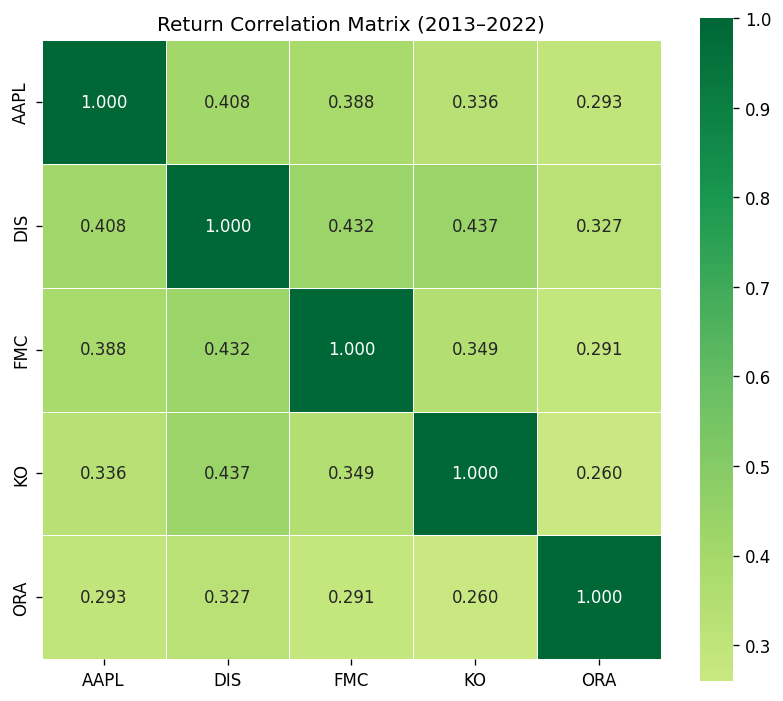


Correlation matrix:
        AAPL     DIS     FMC      KO     ORA
AAPL  1.0000  0.4085  0.3880  0.3358  0.2929
DIS   0.4085  1.0000  0.4317  0.4373  0.3273
FMC   0.3880  0.4317  1.0000  0.3491  0.2911
KO    0.3358  0.4373  0.3491  1.0000  0.2599
ORA   0.2929  0.3273  0.2911  0.2599  1.0000


In [7]:
# Correlation matrix
fig, ax = plt.subplots(figsize=(7, 6))
corr = log_returns.corr()
sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdYlGn', center=0,
            ax=ax, square=True, linewidths=0.5)
ax.set_title('Return Correlation Matrix (2013–2022)')
plt.tight_layout()
plt.savefig('fig_corr_matrix.png', bbox_inches='tight')
plt.show()
print("\nCorrelation matrix:")
print(corr.round(4).to_string())


---
## Task 2: Portfolio Analysis with Mean-Variance Optimization

In [8]:
# Input parameters
mean_ret = log_returns.mean() * 252          # annualised expected returns
cov_mat  = log_returns.cov()  * 252          # annualised covariance matrix
n_stocks = len(STOCKS)
rf       = RF_ANNUAL

print("Annualised Expected Returns:")
for s in STOCKS:
    print(f"  {s}: {mean_ret[s]*100:.2f}%")
print("\nCovariance Matrix (annualised):")
print(cov_mat.round(6).to_string())


Annualised Expected Returns:
  AAPL: 20.44%
  DIS: 6.27%
  FMC: 10.27%
  KO: 8.41%
  ORA: 15.35%

Covariance Matrix (annualised):
          AAPL       DIS       FMC        KO       ORA
AAPL  0.084305  0.031426  0.033900  0.017651  0.026860
DIS   0.031426  0.070200  0.034421  0.020976  0.027390
FMC   0.033900  0.034421  0.090549  0.019018  0.027665
KO    0.017651  0.020976  0.019018  0.032770  0.014857
ORA   0.026860  0.027390  0.027665  0.014857  0.099739


In [9]:
# Monte Carlo efficient frontier
np.random.seed(42)
mc_weights = np.zeros((N_SIM, n_stocks))
mc_returns = np.zeros(N_SIM)
mc_vols    = np.zeros(N_SIM)
mc_sharpes = np.zeros(N_SIM)

for i in range(N_SIM):
    w = np.random.dirichlet(np.ones(n_stocks))
    r = w @ mean_ret.values
    v = np.sqrt(w @ cov_mat.values @ w)
    mc_weights[i], mc_returns[i], mc_vols[i] = w, r, v
    mc_sharpes[i] = (r - rf) / v

print(f"Simulated {N_SIM:,} random portfolios")
print(f"Sharpe range: [{mc_sharpes.min():.3f}, {mc_sharpes.max():.3f}]")


Simulated 10,000 random portfolios
Sharpe range: [0.082, 0.557]


In [10]:
# Equal-weight portfolio
ew_weights = np.array([1/n_stocks] * n_stocks)
ew_ret  = ew_weights @ mean_ret.values
ew_vol  = np.sqrt(ew_weights @ cov_mat.values @ ew_weights)
ew_sr   = (ew_ret - rf) / ew_vol
ew_util = ew_ret - 0.5 * A_COEFF * ew_vol**2

print(f"Equal-Weight Portfolio:")
print(f"  Expected Return (ann.): {ew_ret*100:.2f}%")
print(f"  Volatility (ann.):      {ew_vol*100:.2f}%")
print(f"  Sharpe Ratio:           {ew_sr:.4f}")
print(f"  Utility (A=5):          {ew_util:.4f}")


Equal-Weight Portfolio:
  Expected Return (ann.): 12.15%
  Volatility (ann.):      18.82%
  Sharpe Ratio:           0.3798
  Utility (A=5):          0.0329


In [11]:
# Tangency portfolio (maximum Sharpe ratio)
def neg_sharpe(w, mu, cov, rf):
    r = w @ mu
    v = np.sqrt(w @ cov @ w)
    return -(r - rf) / v

constraints = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1}]
bounds = [(0, 1)] * n_stocks
w0     = np.ones(n_stocks) / n_stocks

res_tan = minimize(neg_sharpe, w0, args=(mean_ret.values, cov_mat.values, rf),
                   method='SLSQP', bounds=bounds, constraints=constraints,
                   options={'ftol': 1e-12, 'maxiter': 1000})
tan_w   = res_tan.x
tan_ret = tan_w @ mean_ret.values
tan_vol = np.sqrt(tan_w @ cov_mat.values @ tan_w)
tan_sr  = (tan_ret - rf) / tan_vol
tan_util= tan_ret - 0.5 * A_COEFF * tan_vol**2

print(f"Tangency Portfolio (max Sharpe, rf={rf*100:.0f}%):")
for s, w in zip(STOCKS, tan_w):
    print(f"  {s}: {w*100:.1f}%")
print(f"  Expected Return: {tan_ret*100:.2f}%")
print(f"  Volatility:      {tan_vol*100:.2f}%")
print(f"  Sharpe Ratio:    {tan_sr:.4f}")
print(f"  Utility (A=5):   {tan_util:.4f}")


Tangency Portfolio (max Sharpe, rf=5%):
  AAPL: 73.4%
  DIS: 0.0%
  FMC: 0.0%
  KO: 0.0%
  ORA: 26.6%
  Expected Return: 19.09%
  Volatility:      25.09%
  Sharpe Ratio:    0.5614
  Utility (A=5):   0.0335


In [12]:
# Maximum Utility portfolio (A=5)
def neg_utility(w, mu, cov, A):
    r    = w @ mu
    vsq  = w @ cov @ w
    return -(r - 0.5 * A * vsq)

res_mu = minimize(neg_utility, w0, args=(mean_ret.values, cov_mat.values, A_COEFF),
                  method='SLSQP', bounds=bounds, constraints=constraints,
                  options={'ftol': 1e-12, 'maxiter': 1000})
mu_w    = res_mu.x
mu_ret  = mu_w @ mean_ret.values
mu_vol  = np.sqrt(mu_w @ cov_mat.values @ mu_w)
mu_sr   = (mu_ret - rf) / mu_vol
mu_util = mu_ret - 0.5 * A_COEFF * mu_vol**2

print(f"Maximum Utility Portfolio (A={A_COEFF}):")
for s, w in zip(STOCKS, mu_w):
    print(f"  {s}: {w*100:.1f}%")
print(f"  Expected Return: {mu_ret*100:.2f}%")
print(f"  Volatility:      {mu_vol*100:.2f}%")
print(f"  Sharpe Ratio:    {mu_sr:.4f}")
print(f"  Utility (A=5):   {mu_util:.4f}")


Maximum Utility Portfolio (A=5):
  AAPL: 41.3%
  DIS: 0.0%
  FMC: 0.0%
  KO: 38.7%
  ORA: 20.0%
  Expected Return: 14.77%
  Volatility:      18.88%
  Sharpe Ratio:    0.5173
  Utility (A=5):   0.0585


In [13]:
# Comparison table
comparison = pd.DataFrame({
    'Equal-Weight': [ew_ret, ew_vol, ew_sr, ew_util],
    'Tangency':     [tan_ret, tan_vol, tan_sr, tan_util],
    'Max-Utility':  [mu_ret, mu_vol, mu_sr, mu_util]
}, index=['Ann. Return', 'Ann. Volatility', 'Sharpe Ratio', 'Utility (A=5)'])

comparison.loc['Ann. Return'] *= 100
comparison.loc['Ann. Volatility'] *= 100
fmt = lambda x: f"{x:.2f}%" if abs(x) < 10 else f"{x:.4f}"
print("Portfolio Comparison:")
print(comparison.applymap(lambda x: f"{x:.4f}"))


Portfolio Comparison:
                Equal-Weight Tangency Max-Utility
Ann. Return          12.1489  19.0875     14.7664
Ann. Volatility      18.8244  25.0932     18.8806
Sharpe Ratio          0.3798   0.5614      0.5173
Utility (A=5)         0.0329   0.0335      0.0585


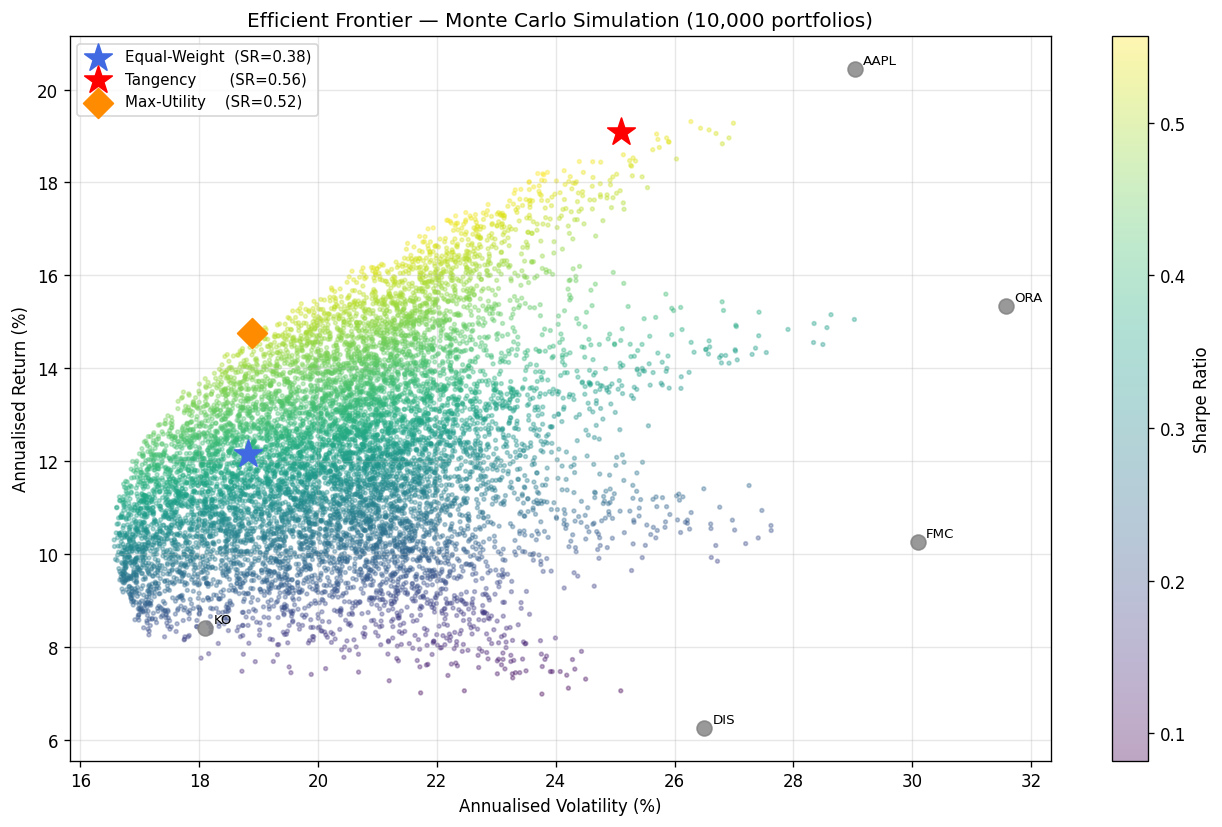

In [14]:
# Efficient frontier plot
fig, ax = plt.subplots(figsize=(11, 7))
sc = ax.scatter(mc_vols*100, mc_returns*100, c=mc_sharpes, cmap='viridis',
                alpha=0.35, s=5)
plt.colorbar(sc, ax=ax, label='Sharpe Ratio')

# Individual assets
ann_vol_s = log_returns.std() * np.sqrt(252)
ann_ret_s = log_returns.mean() * 252
for s in STOCKS:
    ax.scatter(ann_vol_s[s]*100, ann_ret_s[s]*100, marker='o', s=80,
               color='grey', alpha=0.8, zorder=4)
    ax.annotate(s, (ann_vol_s[s]*100, ann_ret_s[s]*100), fontsize=8,
                textcoords='offset points', xytext=(5, 3))

ax.scatter(ew_vol*100, ew_ret*100, marker='*', s=300, color='royalblue',
           zorder=6, label=f'Equal-Weight  (SR={ew_sr:.2f})')
ax.scatter(tan_vol*100, tan_ret*100, marker='*', s=300, color='red',
           zorder=6, label=f'Tangency       (SR={tan_sr:.2f})')
ax.scatter(mu_vol*100, mu_ret*100, marker='D', s=160, color='darkorange',
           zorder=6, label=f'Max-Utility    (SR={mu_sr:.2f})')

ax.set_xlabel('Annualised Volatility (%)'); ax.set_ylabel('Annualised Return (%)')
ax.set_title('Efficient Frontier — Monte Carlo Simulation (10,000 portfolios)')
ax.legend(loc='upper left', fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig_task2_efficient_frontier.png', bbox_inches='tight')
plt.show()


---
## Task 3: Time Series Prediction
### 3a. Detailed modelling — Coca-Cola (KO)

In [15]:
ko = log_returns[ASSIGNED].dropna()
print(f"KO log returns: {len(ko)} observations")
print(f"Range: {ko.index[0].date()} → {ko.index[-1].date()}")

# Train test split (80 / 20)
split = int(len(ko) * 0.8)
train, test = ko.iloc[:split], ko.iloc[split:]
print(f"Train: {len(train)} obs  ({train.index[0].date()} → {train.index[-1].date()})")
print(f"Test:  {len(test)} obs   ({test.index[0].date()} → {test.index[-1].date()})")


KO log returns: 2517 observations
Range: 2013-01-03 → 2022-12-30
Train: 2013 obs  (2013-01-03 → 2020-12-30)
Test:  504 obs   (2020-12-31 → 2022-12-30)


In [16]:
# Stationarity — Augmented Dickey-Fuller test
# H0: unit root (non-stationary).  Reject H0 if p-value < 0.05.
adf = adfuller(ko, autolag='AIC')
print("Augmented Dickey-Fuller Test on KO Log Returns")
print(f"  Test Statistic : {adf[0]:.4f}")
print(f"  p-value        : {adf[1]:.6f}")
print(f"  Critical values: 1%={adf[4]['1%']:.3f}, 5%={adf[4]['5%']:.3f}, 10%={adf[4]['10%']:.3f}")
print(f"  Conclusion     : {'STATIONARY (p < 0.05 → reject H0)' if adf[1] < 0.05 else 'NON-STATIONARY'}")
print("  d = 0 (no differencing required)")


Augmented Dickey-Fuller Test on KO Log Returns
  Test Statistic : -16.0741
  p-value        : 0.000000
  Critical values: 1%=-3.433, 5%=-2.863, 10%=-2.567
  Conclusion     : STATIONARY (p < 0.05 → reject H0)
  d = 0 (no differencing required)


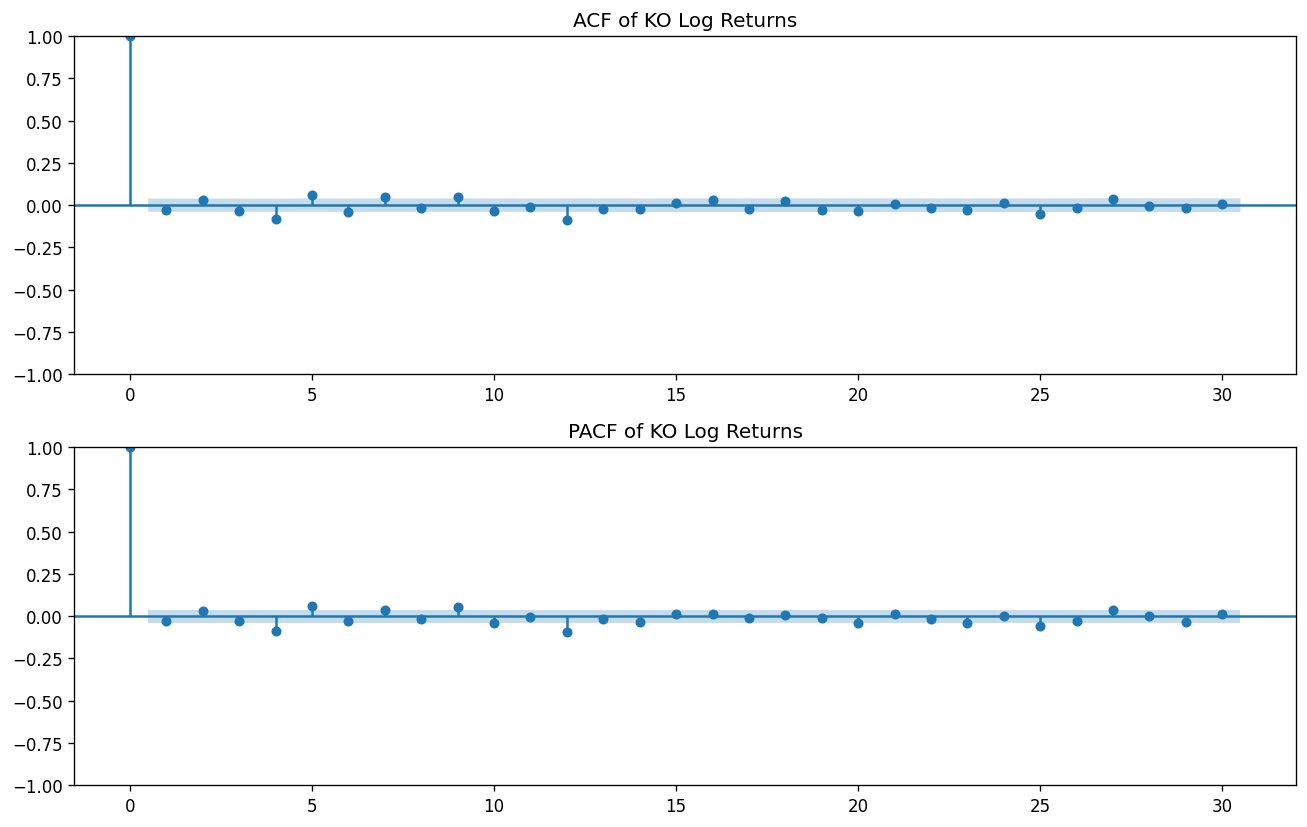

ACF/PACF interpretation:
  ACF cuts off quickly → MA component likely low order
  PACF shows small significant lags at 1 and 2 → AR(2) candidate


In [17]:
# ACF and PACF
fig, axes = plt.subplots(2, 1, figsize=(11, 7))
plot_acf(ko,  lags=30, ax=axes[0], title='ACF of KO Log Returns')
plot_pacf(ko, lags=30, ax=axes[1], title='PACF of KO Log Returns', method='ywm')
plt.tight_layout()
plt.savefig('fig_task3_acf_pacf.png', bbox_inches='tight')
plt.show()
print("ACF/PACF interpretation:")
print("  ACF cuts off quickly → MA component likely low order")
print("  PACF shows small significant lags at 1 and 2 → AR(2) candidate")


In [18]:
# ARIMA model selection (grid search by AIC)
results_aic = {}
for p in range(4):
    for q in range(4):
        try:
            m = ARIMA(train, order=(p, 0, q)).fit()
            results_aic[(p, 0, q)] = m.aic
        except Exception:
            pass

aic_df = pd.Series(results_aic, name='AIC').sort_values()
print("Top 5 ARIMA orders by AIC:")
print(aic_df.head(5).to_string())
best_order = aic_df.idxmin()
print(f"\nSelected: ARIMA{best_order}")


Top 5 ARIMA orders by AIC:
0  0  3   -12281.137141
3  0  2   -12280.548890
      0   -12279.379736
2  0  0   -12278.538490
0  0  2   -12278.462873

Selected: ARIMA(np.int64(0), np.int64(0), np.int64(3))


In [19]:
# Fit best ARIMA
arima_fit = ARIMA(train, order=best_order).fit()
print(arima_fit.summary())


                               SARIMAX Results                                
Dep. Variable:                     KO   No. Observations:                 2013
Model:                 ARIMA(0, 0, 3)   Log Likelihood                6145.569
Date:                Sun, 03 May 2026   AIC                         -12281.137
Time:                        22:56:39   BIC                         -12253.100
Sample:                             0   HQIC                        -12270.846
                               - 2013                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0003      0.000      1.183      0.237      -0.000       0.001
ma.L1         -0.0300      0.011     -2.792      0.005      -0.051      -0.009
ma.L2          0.0355      0.010      3.609      0.0

In [20]:
# Residual diagnostics
residuals = arima_fit.resid

# Ljung-Box on residuals (check for remaining autocorrelation)
lb_resid = acorr_ljungbox(residuals, lags=[10, 20], return_df=True)
print("Ljung-Box test on ARIMA residuals:")
print(lb_resid.to_string())
print("(p > 0.05 → residuals are white noise → adequate mean model)")

# ARCH-LM test (squared residuals → test for volatility clustering)
lb_sq = acorr_ljungbox(residuals**2, lags=[10], return_df=True)
print(f"\nLjung-Box on squared residuals (ARCH effect): p = {lb_sq['lb_pvalue'].values[0]:.4f}")
print("(p < 0.05 → ARCH effects present → GARCH warranted)")


Ljung-Box test on ARIMA residuals:
      lb_stat  lb_pvalue
10  27.934027   0.001850
20  56.377272   0.000026
(p > 0.05 → residuals are white noise → adequate mean model)

Ljung-Box on squared residuals (ARCH effect): p = 0.0000
(p < 0.05 → ARCH effects present → GARCH warranted)


In [21]:
# GARCH(1,1) on ARIMA residuals
garch_spec = arch_model(residuals * 100, vol='Garch', p=1, q=1, dist='normal')
garch_fit  = garch_spec.fit(disp='off')
print(garch_fit.summary())
omega = garch_fit.params['omega']
alpha = garch_fit.params['alpha[1]']
beta  = garch_fit.params['beta[1]']
print(f"\nomega={omega:.6f}, alpha[1]={alpha:.4f}, beta[1]={beta:.4f}")
print(f"Persistence (alpha + beta) = {alpha+beta:.4f}")
print("(close to 1 → high volatility persistence — typical for stocks)")


                     Constant Mean - GARCH Model Results                      
Dep. Variable:                   None   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -2849.42
Distribution:                  Normal   AIC:                           5706.84
Method:            Maximum Likelihood   BIC:                           5729.27
                                        No. Observations:                 2013
Date:                Sun, May 03 2026   Df Residuals:                     2012
Time:                        22:56:39   Df Model:                            1
                                  Mean Model                                 
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
mu             0.0128  3.408e-02      0.375      0.707 

In [22]:
# Rolling one-step-ahead forecast
print(f"Rolling {len(test)}-step forecast...")
history = list(train.values)
pred_ret, pred_vol = [], []

for i in range(len(test)):
    try:
        ar  = ARIMA(history, order=best_order).fit()
        fc  = ar.forecast(steps=1)[0]
        res = ar.resid
    except Exception:
        fc  = np.mean(history[-60:])
        res = np.array(history) - np.mean(history)
    try:
        gc  = arch_model(np.array(res)*100, vol='Garch', p=1, q=1)
        gf  = gc.fit(disp='off')
        vfc = np.sqrt(gf.forecast(horizon=1).variance.values[-1, 0]) / 100
    except Exception:
        vfc = np.std(history[-60:])
    pred_ret.append(fc)
    pred_vol.append(vfc)
    history.append(test.values[i])

pred_ret = np.array(pred_ret)
pred_vol = np.array(pred_vol)
actual   = test.values
print("Forecast complete.")


Rolling 504-step forecast...
Forecast complete.


In [23]:
# Evaluation
rmse    = np.sqrt(np.mean((pred_ret - actual)**2))
mae     = np.mean(np.abs(pred_ret - actual))
dir_acc = np.mean(np.sign(pred_ret) == np.sign(actual))

print(f"Out-of-sample evaluation ({len(test)} days):")
print(f"  RMSE               : {rmse:.6f}")
print(f"  MAE                : {mae:.6f}")
print(f"  Directional Accuracy: {dir_acc*100:.1f}%")


Out-of-sample evaluation (504 days):
  RMSE               : 0.011204
  MAE                : 0.008123
  Directional Accuracy: 49.0%


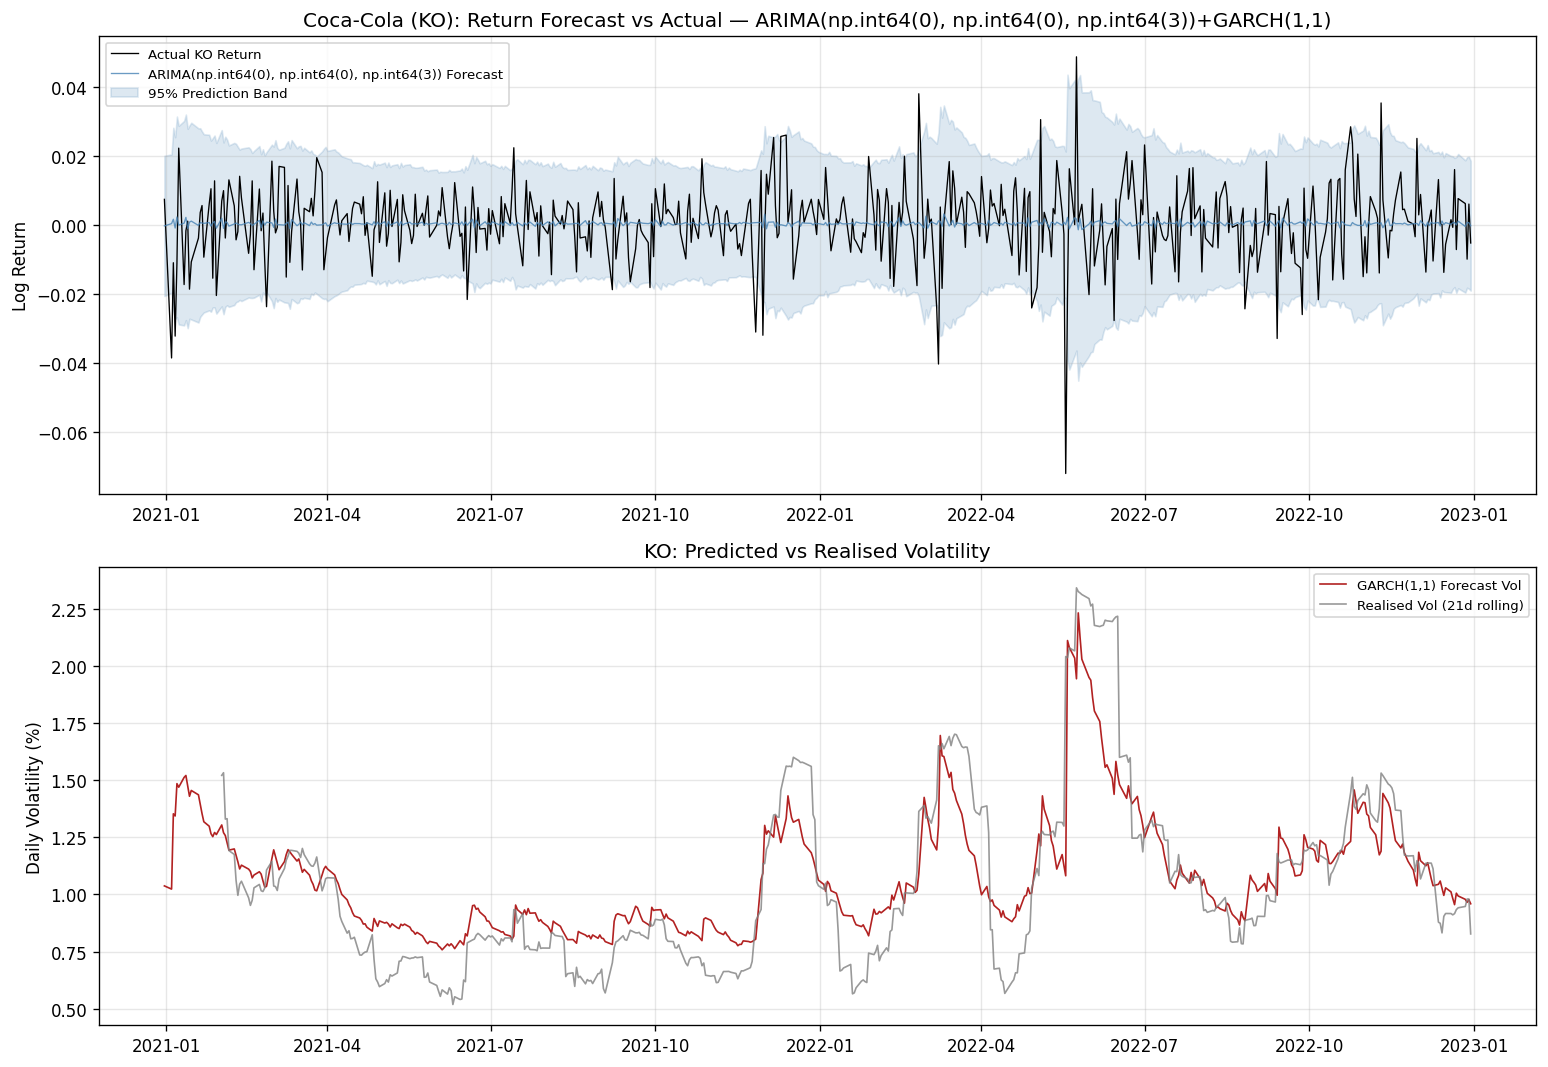

In [24]:
# Forecast plot
fig, axes = plt.subplots(2, 1, figsize=(13, 9))

axes[0].plot(test.index, actual,   label='Actual KO Return', color='black', lw=0.8)
axes[0].plot(test.index, pred_ret, label=f'ARIMA{best_order} Forecast', color='steelblue', lw=0.8, alpha=0.8)
axes[0].fill_between(test.index, pred_ret - 1.96*pred_vol, pred_ret + 1.96*pred_vol,
                     alpha=0.18, color='steelblue', label='95% Prediction Band')
axes[0].set_title(f'Coca-Cola (KO): Return Forecast vs Actual — ARIMA{best_order}+GARCH(1,1)')
axes[0].set_ylabel('Log Return'); axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

real_vol = pd.Series(actual, index=test.index).rolling(21).std()
axes[1].plot(test.index, pred_vol*100, label='GARCH(1,1) Forecast Vol', color='firebrick', lw=1)
axes[1].plot(test.index, real_vol*100,  label='Realised Vol (21d rolling)', color='grey', lw=1, alpha=0.8)
axes[1].set_title('KO: Predicted vs Realised Volatility')
axes[1].set_ylabel('Daily Volatility (%)'); axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fig_task3_ko_forecast.png', bbox_inches='tight')
plt.show()


### 3b. Summary for remaining four assets

In [25]:
# Summary ARIMA-GARCH for all stocks
all_metrics = {}
for stock in STOCKS:
    sr = log_returns[stock].dropna()
    sp = int(len(sr) * 0.8)
    tr, te = sr.iloc[:sp], sr.iloc[sp:]

    # ARIMA selection
    b_aic = np.inf; b_ord = (0, 0, 0)
    for p in range(4):
        for q in range(4):
            try:
                m = ARIMA(tr, order=(p, 0, q)).fit()
                if m.aic < b_aic:
                    b_aic = m.aic; b_ord = (p, 0, q)
            except Exception:
                pass

    try:
        arm  = ARIMA(tr, order=b_ord).fit()
        fc   = arm.forecast(steps=len(te))
        res  = arm.resid
        gc   = arch_model(res*100, vol='Garch', p=1, q=1)
        gf   = gc.fit(disp='off')
        a, b = gf.params['alpha[1]'], gf.params['beta[1]']
        vfc  = gf.forecast(horizon=5).variance.values[-1, :].mean()**0.5 / 100
        rmse_s = np.sqrt(np.mean((fc.values - te.values)**2))
        dir_s  = np.mean(np.sign(fc.values) == np.sign(te.values))
    except Exception:
        a = b = vfc = rmse_s = dir_s = float('nan')

    all_metrics[stock] = {'order': b_ord, 'alpha': a, 'beta': b,
                          'persist': a+b, 'ann_vol_fc': vfc*np.sqrt(252)*100,
                          'RMSE': rmse_s, 'DirAcc': dir_s}

summary_df = pd.DataFrame(all_metrics).T
summary_df.index.name = 'Stock'
print("ARIMA-GARCH Summary — All Stocks:")
print(summary_df[['order','persist','ann_vol_fc','RMSE','DirAcc']]
      .applymap(lambda x: f"{x:.4f}" if isinstance(x, float) else str(x)))


ARIMA-GARCH Summary — All Stocks:
           order persist ann_vol_fc    RMSE  DirAcc
Stock                                              
AAPL   (1, 0, 0)  0.9452    28.9416  0.0194  0.4921
DIS    (1, 0, 0)  0.9811    40.0939  0.0201  0.4563
FMC    (2, 0, 0)  0.9287    23.9035  0.0180  0.5040
KO     (0, 0, 3)  0.9711    16.5064  0.0112  0.5456
ORA    (3, 0, 3)  0.9696    40.5319  0.0250  0.5079


---
## Task 4: Fama-French 3-Factor Analysis

In [26]:
# Load and prepare FF3 data
ff3 = pd.read_csv(FF3_PATH)
ff3.columns = ff3.columns.str.strip()
ff3['Date'] = pd.to_datetime(ff3['Date'].astype(str), format='%Y%m%d')
ff3.set_index('Date', inplace=True)
ff3[['Mkt-RF', 'SMB', 'HML', 'RF']] /= 100
print(f"FF3 data: {ff3.shape[0]} obs, range {ff3.index[0].date()} → {ff3.index[-1].date()}")
print(ff3.head(3).to_string())


FF3 data: 3774 obs, range 2010-01-04 → 2024-12-31
            Mkt-RF     SMB     HML   RF
Date                                   
2010-01-04  0.0169  0.0061  0.0112  0.0
2010-01-05  0.0031 -0.0064  0.0124  0.0
2010-01-06  0.0013 -0.0022  0.0057  0.0


In [27]:
# Alignment with stock returns
simple_ret = prices.pct_change().dropna()
ff3_aligned = ff3.reindex(simple_ret.index).dropna()
ret_aligned  = simple_ret.reindex(ff3_aligned.index)
print(f"Aligned dataset: {len(ff3_aligned)} observations")
print(f"Range: {ff3_aligned.index[0].date()} → {ff3_aligned.index[-1].date()}")


Aligned dataset: 2517 observations
Range: 2013-01-03 → 2022-12-30


In [28]:
# Detailed regression: KO
ko_excess = ret_aligned[ASSIGNED] - ff3_aligned['RF']
X = sm.add_constant(ff3_aligned[['Mkt-RF', 'SMB', 'HML']])

ko_model = sm.OLS(ko_excess, X).fit()
print(ko_model.summary())


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.394
Model:                            OLS   Adj. R-squared:                  0.393
Method:                 Least Squares   F-statistic:                     544.8
Date:                Sun, 03 May 2026   Prob (F-statistic):          1.00e-272
Time:                        22:59:42   Log-Likelihood:                 8330.4
No. Observations:                2517   AIC:                        -1.665e+04
Df Residuals:                    2513   BIC:                        -1.663e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       6.467e-05      0.000      0.366      0.7

In [29]:
# Extract and interpret KO loadings
ko_alpha  = ko_model.params['const']
ko_beta_m = ko_model.params['Mkt-RF']
ko_beta_s = ko_model.params['SMB']
ko_beta_h = ko_model.params['HML']
ko_r2     = ko_model.rsquared

print(f"KO Factor Loadings (with p-values):")
print(f"  Alpha (ann.): {ko_alpha*252*100:.4f}%  p={ko_model.pvalues['const']:.4f}")
print(f"  Market Beta : {ko_beta_m:.4f}          p={ko_model.pvalues['Mkt-RF']:.4f}")
print(f"  SMB Beta    : {ko_beta_s:.4f}          p={ko_model.pvalues['SMB']:.4f}")
print(f"  HML Beta    : {ko_beta_h:.4f}          p={ko_model.pvalues['HML']:.4f}")
print(f"  R-squared   : {ko_r2:.4f}")


KO Factor Loadings (with p-values):
  Alpha (ann.): 1.6296%  p=0.7141
  Market Beta : 0.6168          p=0.0000
  SMB Beta    : -0.4106          p=0.0000
  HML Beta    : 0.2171          p=0.0000
  R-squared   : 0.3941


In [30]:
# FF3 regression: all stocks
ff3_res = {}
for stock in STOCKS:
    ex  = ret_aligned[stock] - ff3_aligned['RF']
    mod = sm.OLS(ex, X).fit()
    ff3_res[stock] = {
        'alpha_ann%': mod.params['const'] * 252 * 100,
        'beta_M'    : mod.params['Mkt-RF'],
        'beta_SMB'  : mod.params['SMB'],
        'beta_HML'  : mod.params['HML'],
        'R2'        : mod.rsquared,
        'alpha_p'   : mod.pvalues['const'],
    }

ff3_df = pd.DataFrame(ff3_res).T
print("FF3 Regression Summary — All Stocks:")
print(ff3_df.round(4).to_string())


FF3 Regression Summary — All Stocks:
      alpha_ann%  beta_M  beta_SMB  beta_HML      R2  alpha_p
AAPL      9.6052  1.1368   -0.3236   -0.4094  0.5277   0.1284
DIS      -2.9191  0.9903    0.0351    0.2167  0.4598   0.6366
FMC       1.6976  1.0405    0.1967    0.4255  0.4311   0.8133
KO        1.6296  0.6168   -0.4106    0.2171  0.3941   0.7141
ORA      10.5349  0.7798    0.5657    0.1063  0.2565   0.2231


In [31]:
# Portfolio factor exposure (Max-Utility weights)
# mu_w from Task 2
port_alpha_ann = sum(mu_w[i] * ff3_res[s]['alpha_ann%'] for i, s in enumerate(STOCKS))
port_beta_m    = sum(mu_w[i] * ff3_res[s]['beta_M']     for i, s in enumerate(STOCKS))
port_beta_s    = sum(mu_w[i] * ff3_res[s]['beta_SMB']   for i, s in enumerate(STOCKS))
port_beta_h    = sum(mu_w[i] * ff3_res[s]['beta_HML']   for i, s in enumerate(STOCKS))

print("Max-Utility Portfolio Factor Exposure:")
print(f"  Alpha (ann.) : {port_alpha_ann:.4f}%")
print(f"  Market Beta  : {port_beta_m:.4f}")
print(f"  SMB Beta     : {port_beta_s:.4f}")
print(f"  HML Beta     : {port_beta_h:.4f}")


Max-Utility Portfolio Factor Exposure:
  Alpha (ann.) : 6.7041%
  Market Beta  : 0.8640
  SMB Beta     : -0.1792
  HML Beta     : -0.0636


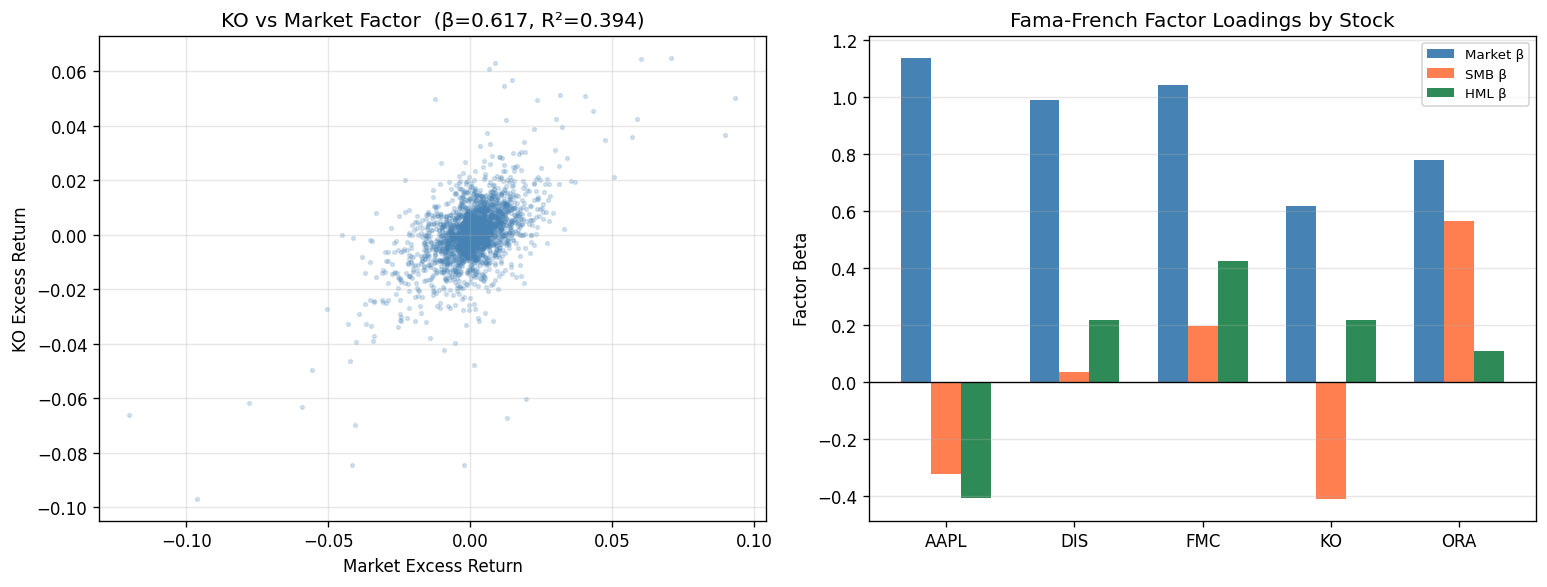

Saved fig_task4_ff3_ko.png and fig_task4_ff3_all.png


In [32]:
# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(X['Mkt-RF'], ko_excess, alpha=0.2, s=5, color='steelblue')
axes[0].set_xlabel('Market Excess Return'); axes[0].set_ylabel('KO Excess Return')
axes[0].set_title(f'KO vs Market Factor  (β={ko_beta_m:.3f}, R²={ko_r2:.3f})')
axes[0].grid(alpha=0.3)

coef_plot = pd.DataFrame({
    'Market β': [ff3_res[s]['beta_M']   for s in STOCKS],
    'SMB β'   : [ff3_res[s]['beta_SMB'] for s in STOCKS],
    'HML β'   : [ff3_res[s]['beta_HML'] for s in STOCKS],
}, index=STOCKS)
coef_plot.plot(kind='bar', ax=axes[1], color=['steelblue','coral','seagreen'], width=0.7)
axes[1].set_title('Fama-French Factor Loadings by Stock')
axes[1].axhline(0, color='black', lw=0.8)
axes[1].set_ylabel('Factor Beta')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('fig_task4_ff3.png', bbox_inches='tight')
plt.show()

# Save panels separately for the report
fig_ko, ax_ko = plt.subplots(figsize=(6, 5))
ax_ko.scatter(X['Mkt-RF'], ko_excess, alpha=0.2, s=5, color='steelblue')
ax_ko.set_xlabel('Market Excess Return'); ax_ko.set_ylabel('KO Excess Return')
ax_ko.set_title(f'KO vs Market Factor  (β={ko_beta_m:.3f}, R²={ko_r2:.3f})')
ax_ko.grid(alpha=0.3)
fig_ko.tight_layout()
fig_ko.savefig('fig_task4_ff3_ko.png', bbox_inches='tight')
plt.close(fig_ko)

fig_all, ax_all = plt.subplots(figsize=(6, 5))
coef_plot.plot(kind='bar', ax=ax_all, color=['steelblue','coral','seagreen'], width=0.7)
ax_all.set_title('Fama-French Factor Loadings by Stock')
ax_all.axhline(0, color='black', lw=0.8)
ax_all.set_ylabel('Factor Beta')
ax_all.tick_params(axis='x', rotation=0)
ax_all.legend(fontsize=8); ax_all.grid(alpha=0.3, axis='y')
fig_all.tight_layout()
fig_all.savefig('fig_task4_ff3_all.png', bbox_inches='tight')
plt.close(fig_all)
print("Saved fig_task4_ff3_ko.png and fig_task4_ff3_all.png")


---
## Task 5: Risk and Performance Evaluation

In [33]:
# Recommended portfolio: Max-Utility (mu_w)
port_daily = log_returns @ mu_w      # max-utility daily returns
ew_daily   = log_returns @ ew_weights
rf_daily   = RF_ANNUAL / 252

print("Max-Utility Portfolio Daily Returns:")
print(f"  Mean  : {port_daily.mean():.6f}")
print(f"  Std   : {port_daily.std():.6f}")
print(f"  Min   : {port_daily.min():.6f}")
print(f"  Max   : {port_daily.max():.6f}")


Max-Utility Portfolio Daily Returns:
  Mean  : 0.000586
  Std   : 0.011894
  Min   : -0.095999
  Max   : 0.082856


In [34]:
# VaR and Expected Shortfall (95%)
conf     = 0.95
alpha_v  = 1 - conf       # 0.05

# Historical (non-parametric)
var_hist = port_daily.quantile(alpha_v)
es_hist  = port_daily[port_daily <= var_hist].mean()

# Parametric (Gaussian)
mu_d   = port_daily.mean()
sig_d  = port_daily.std()
var_par = norm.ppf(alpha_v) * sig_d + mu_d
es_par  = mu_d - sig_d * norm.pdf(norm.ppf(alpha_v)) / alpha_v

print("VaR and ES — Max-Utility Portfolio (95% confidence):")
print(f"  Historical VaR : {var_hist*100:.4f}%  per day")
print(f"  Parametric VaR : {var_par*100:.4f}%  per day")
print(f"  Historical ES  : {es_hist*100:.4f}%  per day")
print(f"  Parametric ES  : {es_par*100:.4f}%  per day")
print("(Negative sign means loss)")


VaR and ES — Max-Utility Portfolio (95% confidence):
  Historical VaR : -1.7669%  per day
  Parametric VaR : -1.8977%  per day
  Historical ES  : -2.8665%  per day
  Parametric ES  : -2.3947%  per day
(Negative sign means loss)


In [35]:
# VaR Backtesting
window = 252
rolling_var = port_daily.rolling(window).quantile(alpha_v)
breaches    = (port_daily < rolling_var).sum()
breach_rate = breaches / len(port_daily)

print(f"VaR Backtesting (rolling {window}-day window):")
print(f"  Total observations : {len(port_daily)}")
print(f"  VaR breaches       : {breaches}")
print(f"  Breach rate        : {breach_rate*100:.2f}%  (expected: 5.00%)")
if breach_rate < 0.04:
    print("  Assessment: VaR model is conservative — may overstate risk")
elif breach_rate < 0.065:
    print("  Assessment: VaR model is well-calibrated")
else:
    print("  Assessment: VaR model underestimates tail risk — consider EVT or Student-t")


VaR Backtesting (rolling 252-day window):
  Total observations : 2517
  VaR breaches       : 131
  Breach rate        : 5.20%  (expected: 5.00%)
  Assessment: VaR model is well-calibrated


In [36]:
# Performance metrics
ann  = np.sqrt(252)

def perf(returns, label):
    excess_d = returns - rf_daily
    sharpe   = (excess_d.mean() * 252) / (returns.std() * ann)
    dd_std   = returns[returns < 0].std() * ann
    sortino  = (excess_d.mean() * 252) / dd_std
    cum      = (1 + returns).cumprod()
    mdd      = ((cum - cum.cummax()) / cum.cummax()).min()
    return {'Label': label,
            'Ann Return': f"{returns.mean()*252*100:.2f}%",
            'Ann Vol'   : f"{returns.std()*ann*100:.2f}%",
            'Sharpe'    : f"{sharpe:.4f}",
            'Sortino'   : f"{sortino:.4f}",
            'Max DD'    : f"{mdd*100:.2f}%"}

perf_df = pd.DataFrame([perf(port_daily, 'Max-Utility'), perf(ew_daily, 'Equal-Weight')])
print(perf_df.set_index('Label').to_string())


             Ann Return Ann Vol  Sharpe Sortino   Max DD
Label                                                   
Max-Utility      14.77%  18.88%  0.5173  0.6604  -34.21%
Equal-Weight     12.15%  18.82%  0.3798  0.4750  -36.91%


In [37]:
# Stress tests
# 1. Historical: COVID crash (Feb–Mar 2020)
covid_ret  = log_returns.loc['2020-02-20':'2020-03-23']
covid_loss = (covid_ret @ mu_w).sum()
covid_days = len(covid_ret)

print(f"Historical stress test — COVID crash (20 Feb → 23 Mar 2020):")
print(f"  Cumulative portfolio return ({covid_days} trading days): {covid_loss*100:.2f}%")
print(f"\n  Per-stock cumulative return over the crash:")
for s in STOCKS:
    stock_loss = covid_ret[s].sum()
    print(f"    {s}: {stock_loss*100:.1f}%")

# 2. Designed scenario
scenario     = {'AAPL': -0.30, 'DIS': -0.40, 'FMC': -0.20, 'KO': -0.15, 'ORA': -0.25}
scenario_arr = np.array([scenario[s] for s in STOCKS])
scenario_loss = mu_w @ scenario_arr
print(f"\nDesigned scenario (AAPL -30%, DIS -40%, FMC -20%, KO -15%, ORA -25%):")
print(f"  Portfolio loss: {scenario_loss*100:.2f}%")

# 3. Comparison with daily ES
print(f"\nComparison with daily risk measures:")
print(f"  Daily ES (95%, historical): {es_hist*100:.2f}%")
print(f"  COVID crash loss           : {covid_loss*100:.2f}%")
print(f"  Designed scenario loss     : {scenario_loss*100:.2f}%")
print(f"  → Both stress losses far exceed daily ES — VaR/ES are day-horizon")
print(f"    measures and must not be used to size tolerance against a multi-week crisis.")

Historical stress test — COVID crash (20 Feb → 23 Mar 2020):
  Cumulative portfolio return (23 trading days): -38.76%

  Per-stock cumulative return over the crash:
    AAPL: -36.6%
    DIS: -49.9%
    FMC: -50.6%
    KO: -45.6%
    ORA: -30.0%

Designed scenario (AAPL -30%, DIS -40%, FMC -20%, KO -15%, ORA -25%):
  Portfolio loss: -23.19%

Comparison with daily risk measures:
  Daily ES (95%, historical): -2.87%
  COVID crash loss           : -38.76%
  Designed scenario loss     : -23.19%
  → Both stress losses far exceed daily ES — VaR/ES are day-horizon
    measures and must not be used to size tolerance against a multi-week crisis.


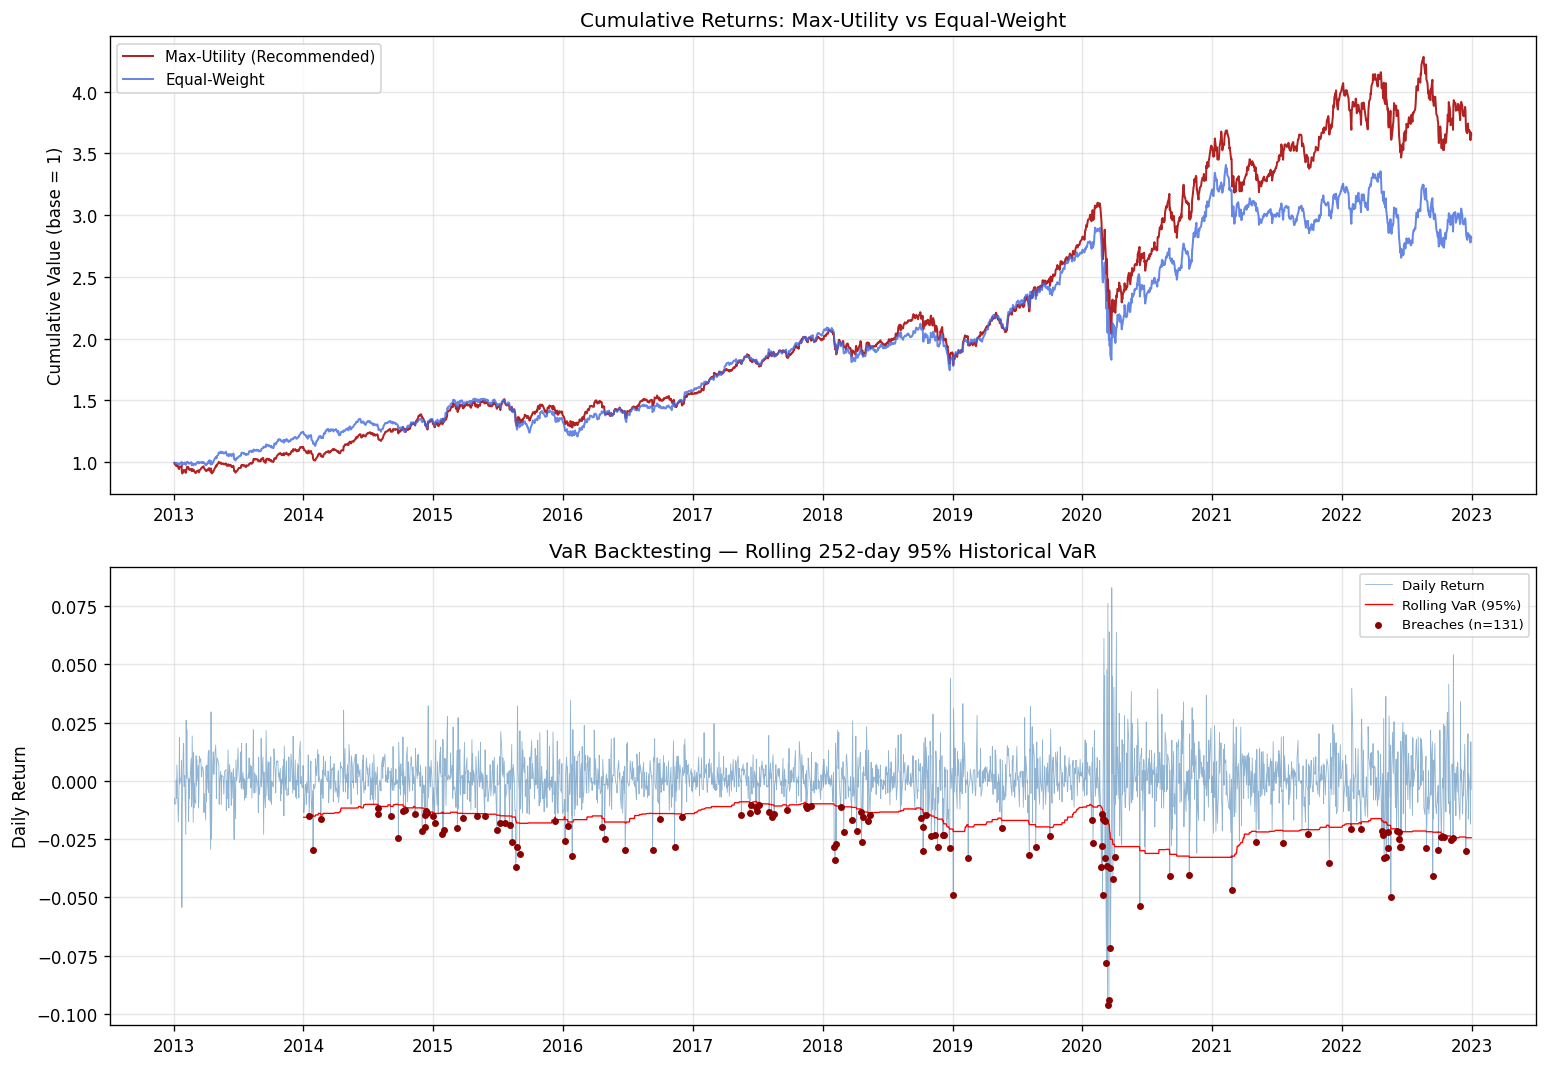

In [38]:
# Visualisation: cumulative returns + VaR backtesting
fig, axes = plt.subplots(2, 1, figsize=(13, 9))

cum_mu = (1 + port_daily).cumprod()
cum_ew = (1 + ew_daily).cumprod()
axes[0].plot(cum_mu, label='Max-Utility (Recommended)', color='firebrick', lw=1.2)
axes[0].plot(cum_ew, label='Equal-Weight',              color='royalblue', lw=1.2, alpha=0.8)
axes[0].set_title('Cumulative Returns: Max-Utility vs Equal-Weight')
axes[0].set_ylabel('Cumulative Value (base = 1)')
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

axes[1].plot(port_daily.index, port_daily.values, color='steelblue', lw=0.5, alpha=0.6, label='Daily Return')
axes[1].plot(rolling_var.index, rolling_var.values, color='red', lw=0.8, label='Rolling VaR (95%)')
bd = port_daily.index[port_daily < rolling_var]
axes[1].scatter(bd, port_daily[bd], color='darkred', s=10, zorder=5, label=f'Breaches (n={breaches})')
axes[1].set_title('VaR Backtesting — Rolling 252-day 95% Historical VaR')
axes[1].set_ylabel('Daily Return'); axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fig_task5_risk.png', bbox_inches='tight')
plt.show()
